# **New Section # 20**

**Building a Machine Learning Pipeline**

In [15]:
import pandas as pd
import numpy as np

# Create a simple dataset with outliers
data = pd.DataFrame({
    "Income": [25, 27, 30, 32, 34, 35, 40, 42, 45, 47, 50, 55, 60, 100, 200, 500]
})

print("Original Data:\n", data)

Original Data:
     Income
0       25
1       27
2       30
3       32
4       34
5       35
6       40
7       42
8       45
9       47
10      50
11      55
12      60
13     100
14     200
15     500


🔹 1. Trimming (Removing Outliers)


In [16]:
# Trim outliers
q_low = data["Income"].quantile(0.05)
q_high = data["Income"].quantile(0.95)

trimmed_data = data[(data["Income"] >= q_low) & (data["Income"] <= q_high)]

print("\nAfter Trimming (Outliers Removed):\n", trimmed_data)


After Trimming (Outliers Removed):
     Income
1       27
2       30
3       32
4       34
5       35
6       40
7       42
8       45
9       47
10      50
11      55
12      60
13     100
14     200


🔹 2. Capping / Winsorization (Replace Outliers)


In [17]:
from scipy.stats.mstats import winsorize

# Convert to numpy array
income = data["Income"].values

# Apply winsorization: 5% from both sides
capped_income = winsorize(income, limits=[0.05, 0.05])

data["Capped_Income"] = capped_income

print("\nAfter Capping (Outliers Replaced):\n", data)


After Capping (Outliers Replaced):
     Income  Capped_Income
0       25             25
1       27             27
2       30             30
3       32             32
4       34             34
5       35             35
6       40             40
7       42             42
8       45             45
9       47             47
10      50             50
11      55             55
12      60             60
13     100            100
14     200            200
15     500            500


🔹 3. Discretization (Binning)


In [18]:
bins = [0, 40, 70, 500]  # Define range bins
labels = ["Low", "Medium", "High"]

data["Income_Level"] = pd.cut(data["Income"], bins=bins, labels=labels)

print("\nAfter Discretization (Binning):\n", data)


After Discretization (Binning):
     Income  Capped_Income Income_Level
0       25             25          Low
1       27             27          Low
2       30             30          Low
3       32             32          Low
4       34             34          Low
5       35             35          Low
6       40             40          Low
7       42             42       Medium
8       45             45       Medium
9       47             47       Medium
10      50             50       Medium
11      55             55       Medium
12      60             60       Medium
13     100            100         High
14     200            200         High
15     500            500         High


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

df = pd.read_csv(r"D:\Codes\MachineLearning\Datasets\salary-package1.csv")
df

,gender,cgpa,iq,salary
0,Male,2.3,Medium,68
1,Female,3.8,High,100
2,Male,3.0,Medium,75
3,Female,NaN,Low,48
4,Female,2.3,High,97
...,...,...,...,...
95,Female,2.1,Low,40
96,Female,2.3,High,68
97,Female,3.8,High,100
98,Female,3.0,Medium,75


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   gender  100 non-null    object 
 1   cgpa    90 non-null     float64
 2   iq      100 non-null    object 
 3   salary  100 non-null    int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 3.3+ KB


In [21]:
df.isna().sum()

gender     0
cgpa      10
iq         0
salary     0
dtype: int64

In [22]:
df.iq.unique()

array(['Medium', 'High', 'Low'], dtype=object)

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
X = df.drop('salary', axis=1)
y = df['salary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [24]:
si = SimpleImputer(strategy='mean', missing_values=np.nan)
si.fit(X_train[['cgpa']])

,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [25]:
X_train['cgpa'] = si.transform(X_train[['cgpa']])
X_test['cgpa'] = si.transform(X_test[['cgpa']])
X_train.isna().sum() + X_test.isna().sum()

gender    0
cgpa      0
iq        0
dtype: int64

In [26]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

ohe = OneHotEncoder(drop='first', sparse_output=False, dtype=np.int32)

ohe.fit(X_train[['gender']])

X_train['gender'] = ohe.transform(X_train[['gender']])
X_test['gender'] = ohe.transform(X_test[['gender']])

X_train

,gender,cgpa,iq
0,1,2.300000,Medium
1,0,3.800000,High
2,1,3.000000,Medium
3,0,2.884507,Low
4,0,2.300000,High
...,...,...,...
75,1,4.000000,Low
76,1,3.100000,Low
77,0,2.800000,Medium
78,1,2.500000,Low


In [27]:
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder(categories=[['Low', 'Medium', 'High']], dtype=np.int8)

oe.fit(X_train[['iq']])

X_train['iq'] = oe.transform(X_train[['iq']])
X_test['iq'] = oe.transform(X_test[['iq']])
X_train

,gender,cgpa,iq
0,1,2.300000,1
1,0,3.800000,2
2,1,3.000000,1
3,0,2.884507,0
4,0,2.300000,2
...,...,...,...
75,1,4.000000,0
76,1,3.100000,0
77,0,2.800000,1
78,1,2.500000,0


In [28]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
test_features =  np.array(['Male', 3.5, 'High']).reshape(1,3)
test_features_transform =  np.array([1, 3.5, 2]).reshape(1,3)
test_features, test_features_transform

lr.predict(test_features_transform)

d:\Codes\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([73.12721804])

**Using Column Transformer:**


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder , OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

df = pd.read_csv(r"D:\Codes\MachineLearning\Datasets\salary-package1.csv")
df

,gender,cgpa,iq,salary
0,Male,2.3,Medium,68
1,Female,3.8,High,100
2,Male,3.0,Medium,75
3,Female,NaN,Low,48
4,Female,2.3,High,97
...,...,...,...,...
95,Female,2.1,Low,40
96,Female,2.3,High,68
97,Female,3.8,High,100
98,Female,3.0,Medium,75


In [31]:
oe = OrdinalEncoder(categories=[['Low', 'Medium', 'High']], dtype=np.int8)
ohe = OneHotEncoder(drop='first', sparse_output=False, dtype=np.int32)
si = SimpleImputer(strategy='mean', missing_values=np.nan)
X = df.drop('salary', axis=1)
y = df['salary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [32]:
transformer1 = ColumnTransformer(
    transformers=[
        ('tmf1', ohe,['gender']),
        ('tmf2', si, ['cgpa']),
        ('tmf3', oe, ['iq'])
    ],
    remainder='passthrough'
)

transformer1.fit(X_train)

,transformers,"[('tmf1', ...), ('tmf2', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,'first'
,sparse_output,False


In [33]:
arr_X_train =  transformer1.transform(X_train)
arr_X_test =  transformer1.transform(X_test)
arr_X_test

array([[0.        , 2.3       , 0.        ],
       [1.        , 3.8       , 0.        ],
       [1.        , 3.        , 1.        ],
       [0.        , 2.1       , 0.        ],
       [0.        , 2.3       , 2.        ],
       [0.        , 3.1       , 0.        ],
       [1.        , 2.4       , 0.        ],
       [1.        , 1.8       , 2.        ],
       [0.        , 1.1       , 0.        ],
       [1.        , 3.2       , 2.        ],
       [0.        , 3.6       , 1.        ],
       [1.        , 4.        , 0.        ],
       [0.        , 3.1       , 2.        ],
       [1.        , 2.8       , 0.        ],
       [1.        , 3.7       , 2.        ],
       [0.        , 2.1       , 0.        ],
       [0.        , 2.3       , 2.        ],
       [0.        , 3.8       , 2.        ],
       [0.        , 3.        , 1.        ],
       [0.        , 2.88450704, 2.        ]])

In [34]:
from sklearn.linear_model import LinearRegression
lr2 = LinearRegression()
lr2.fit(arr_X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [35]:
test_features =  np.array(['Male', 3.5, 'High']).reshape(1,3)
test_features_transform =  np.array([1, 3.5, 2]).reshape(1,3)
test_features, test_features_transform


(array([['Male', '3.5', 'High']], dtype='<U32'), array([[1. , 3.5, 2. ]]))

In [36]:
lr2.predict(test_features_transform)


array([73.12721804])

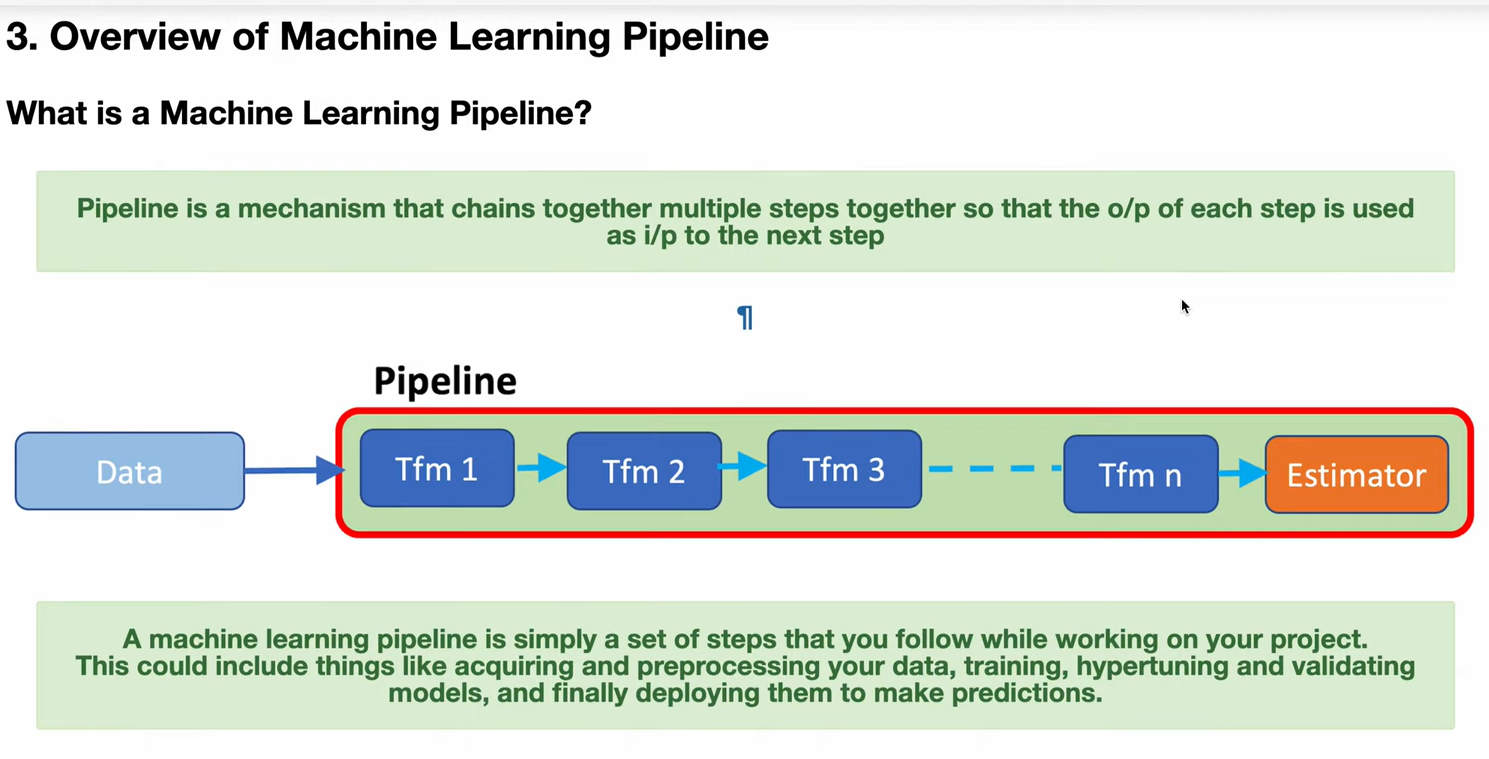


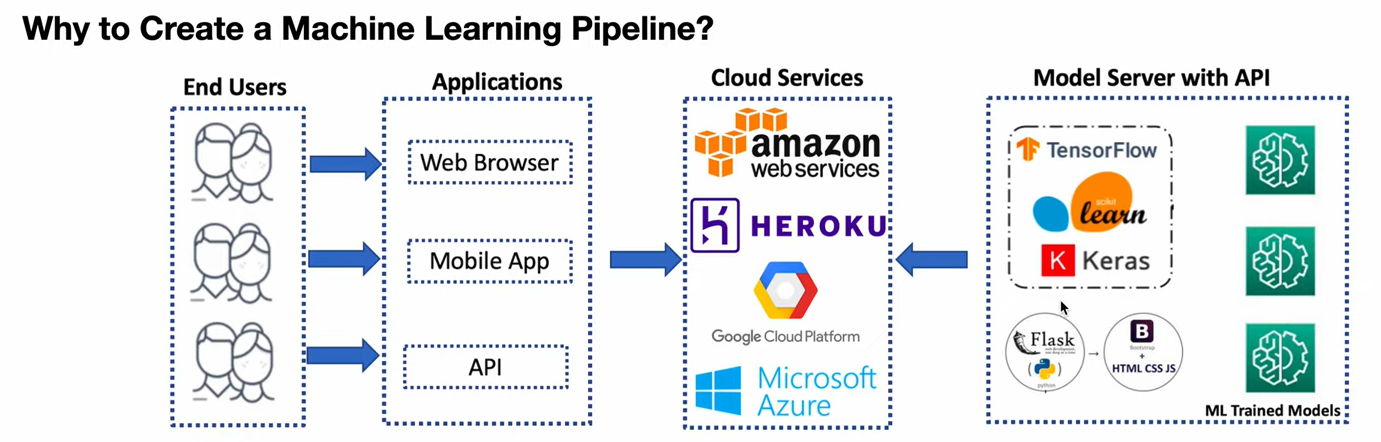


**Creating Machine Learning Pipeline:**


In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder , OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

df = pd.read_csv(r'D:\Codes\MachineLearning\Datasets\advertising-withmissingdata.csv')
df

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,NaN,45.1,10.4
2,NaN,45.9,69.3,9.3
3,151.5,41.3,NaN,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,NaN,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,NaN,25.5


In [38]:
X = df.drop('sales', axis=1)
y = df['sales']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)



In [39]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


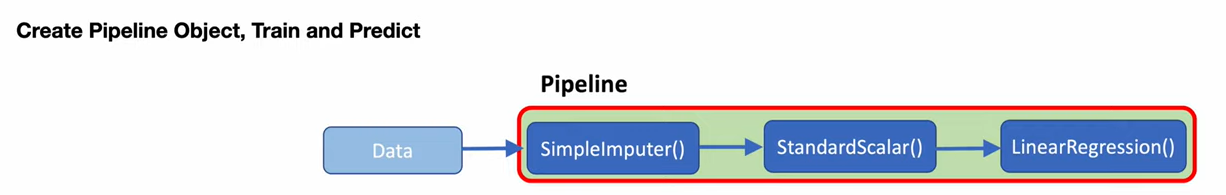


In [40]:
pipe = Pipeline(steps=[
    ('si', SimpleImputer(strategy='mean', missing_values=np.nan)),
    ('ss', StandardScaler()),
    ('lr', LinearRegression())
])
pipe

,steps,"[('si', ...), ('ss', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [41]:
from sklearn import set_config
set_config(display='daigram')

In [42]:
pipe.fit(X_train,y_train)


Pipeline(steps=[('si', SimpleImputer()), ('ss', StandardScaler()),
                ('lr', LinearRegression())])

In [43]:
pipe.predict(X_test)


array([14.28840334, 13.3483316 , 15.03030333, 17.15166151, 11.10369844,
       14.60874663, 10.49348363, 13.62111358, 17.26330904, 18.18840605,
        7.4218397 , 14.4095331 ,  7.49584567, 12.160412  , 14.03239124,
       24.58102684, 19.95915873, 12.37103048, 16.37704151, 11.51935093,
       10.8174738 , 14.20402747,  6.67604003, 24.04833435, 18.648371  ,
       20.55109732,  9.933681  , 17.01864598, 18.84750113,  6.04848057,
       12.11523271, 11.65817749,  4.57336947, 18.21932334, 16.29589307,
        5.48119906, 11.74635607, 12.94786298, 23.67950171, 11.27185921])

In [44]:
pipe.score(X_test,y_test)


0.8907155067664339

In [45]:
pipe['si'].fit_transform(X_test)


array([[172.5       ,  18.1       ,  30.7       ],
       [ 85.7       ,  35.8       ,  49.3       ],
       [188.4       ,  18.1       ,  25.6       ],
       [163.5       ,  36.8       ,   7.4       ],
       [117.2       ,  14.7       ,   5.4       ],
       [234.5       ,   3.4       ,  84.8       ],
       [ 17.9       ,  37.6       ,  21.6       ],
       [206.8       ,   5.2       ,  19.4       ],
       [215.4       ,  23.6       ,  57.6       ],
       [284.3       ,  10.6       ,   6.4       ],
       [ 50.        ,  11.6       ,  18.4       ],
       [164.5       ,  20.9       ,  47.4       ],
       [ 19.6       ,  20.1       ,  17.        ],
       [168.4       ,   7.1       ,  12.8       ],
       [222.4       ,   3.4       ,  13.1       ],
       [276.9       ,  48.9       ,  41.8       ],
       [248.4       ,  30.2       ,  20.3       ],
       [170.2       ,   7.8       ,  35.2       ],
       [276.7       ,   2.3       ,  23.7       ],
       [163.85135135,  10.     

In [46]:
TV = 60
radio = np.nan
newspaper = 40
input_features =np.array([[TV, radio, newspaper]])
pipe.predict(input_features)

d:\Codes\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


array([9.20351997])

**New Data Set:**


In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder , OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer


df = pd.read_csv(r"D:\Codes\MachineLearning\Datasets\tips-missingdata.csv")
df

,total_bill,sex,smoker,day,time,size,tip
0,16.99,Female,No,Sun,Dinner,2,NaN
1,NaN,Male,NaN,Sun,Dinner,3,1.66
2,21.01,Male,No,Sun,Dinner,3,3.50
3,23.68,NaN,No,Sun,Dinner,2,3.31
4,24.59,Female,No,Sun,Dinner,4,3.61
...,...,...,...,...,...,...,...
239,29.03,Male,No,Sat,Dinner,3,5.92
240,27.18,Female,Yes,Sat,Dinner,2,2.00
241,22.67,Male,Yes,Sat,Dinner,2,2.00
242,NaN,Male,No,Sat,Dinner,2,1.75


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  241 non-null    float64
 1   sex         242 non-null    object 
 2   smoker      243 non-null    object 
 3   day         244 non-null    object 
 4   time        244 non-null    object 
 5   size        244 non-null    int64  
 6   tip         243 non-null    float64
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [49]:
df.isna().sum()

total_bill    3
sex           2
smoker        1
day           0
time          0
size          0
tip           1
dtype: int64

In [50]:
df.dropna(axis=0, how='any', subset=['tip'], inplace=True )
df.isna().sum()

total_bill    3
sex           2
smoker        1
day           0
time          0
size          0
tip           0
dtype: int64

In [51]:
X = df.drop('tip', axis=1)
y = df['tip']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

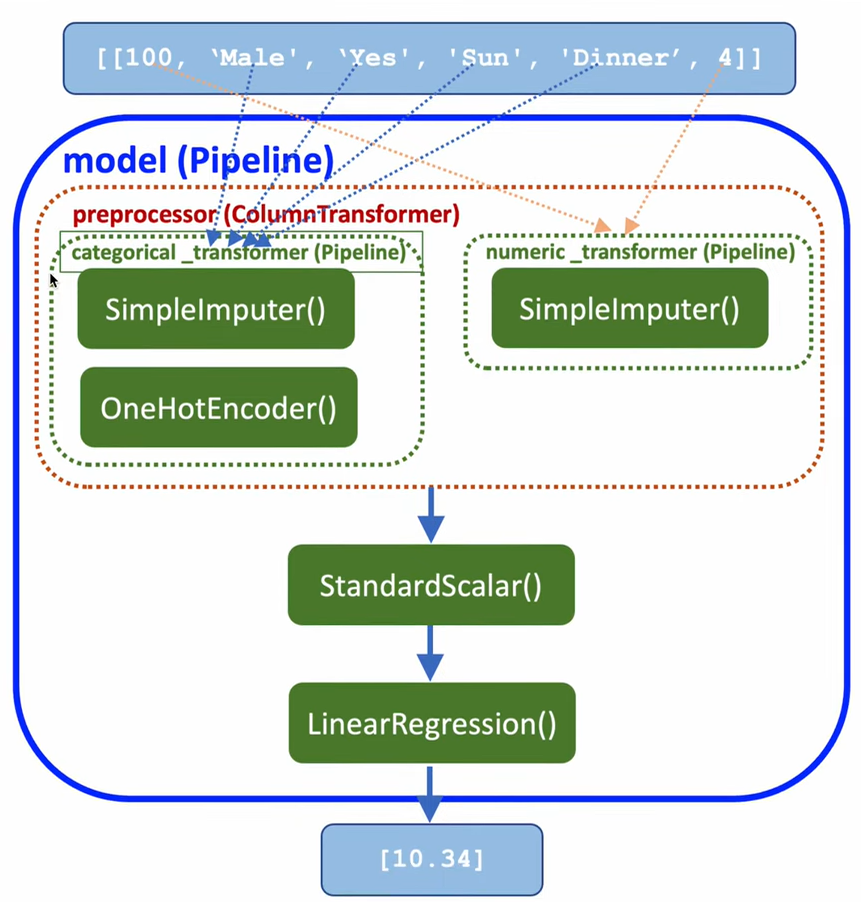


In [52]:
df.columns

Index(['total_bill', 'sex', 'smoker', 'day', 'time', 'size', 'tip'], dtype='object')

In [53]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# catagorial data sex	smoker	day	time.

catagorial_pipe = Pipeline(steps=[
    ('si', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Numeric pipe  total_bill size

Numeric_pipe = Pipeline(steps=[
    ('si', SimpleImputer(missing_values=np.nan, strategy='mean'))
])

In [54]:
from sklearn.compose import ColumnTransformer

preprocessing = ColumnTransformer(transformers=[
    ('catagoriacl', catagorial_pipe, [1,2,3,4]),
    ('numerical',  Numeric_pipe, [0,5])
  ]
)

In [55]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

model_pipe = Pipeline(steps=[
    ('preprocessing', preprocessing),
    ('scaling', StandardScaler()),
    ('regressor', LinearRegression())
  ]
)



In [56]:
model_pipe

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('catagoriacl',
                                                  Pipeline(steps=[('si',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  [1, 2, 3, 4]),
                                                 ('numerical',
                                                  Pipeline(steps=[('si',
                                                                   SimpleImputer())]),
                                                  [0, 5])])),
                ('scaling', StandardScaler()),
                ('regressor', LinearRegress

In [57]:
from sklearn import set_config
set_config(display='diagram')
model_pipe

,steps,"[('preprocessing', ...), ('scaling', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('catagoriacl', ...), ('numerical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [58]:
model_pipe.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('scaling', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('catagoriacl', ...), ('numerical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [59]:
y_pred = model_pipe.predict(X_test)

In [60]:
residuals =  y_test - y_pred
residuals.sum()

np.float64(-13.522108544010994)

In [61]:
model_pipe.score(X_test, y_test)

0.38740214812599993

In [62]:
total_bill = 100
sex = 'Male'
smoker = 'Yes'
day = 'Sun'
time = 'Dinner'
size = 4

test_input = np.array([[total_bill, sex, smoker, day, time, size]], dtype='object')

In [63]:
model_pipe.predict(test_input)

d:\Codes\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
d:\Codes\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


array([10.77959822])

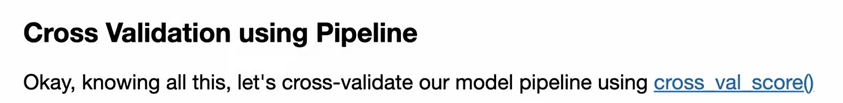


In [64]:
from sklearn.model_selection import cross_val_score
arr_cross_check = cross_val_score(model_pipe, X_train,y_train, cv=5, scoring='r2')

d:\Codes\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [65]:
arr_cross_check.mean()

np.float64(0.3994264512637022)

## **Practice Hyperparams, ColumnTransformer, Pipe and Model**
**Create Pipe Line for Big Mart Store**

uisng big_mart_sales Dataset


In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn import set_config

df = pd.read_csv(r'D:\Codes\MachineLearning\Datasets\big_mart_sales.csv')
df.head(10)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
5,FDP36,10.395,Regular,0.000000,Baking Goods,51.4008,OUT018,2009,Medium,Tier 3,Supermarket Type2,556.6088
6,FDO10,13.650,Regular,0.012741,Snack Foods,57.6588,OUT013,1987,High,Tier 3,Supermarket Type1,343.5528
7,FDP10,NaN,Low Fat,0.127470,Snack Foods,107.7622,OUT027,1985,Medium,Tier 3,Supermarket Type3,4022.7636
8,FDH17,16.200,Regular,0.016687,Frozen Foods,96.9726,OUT045,2002,NaN,Tier 2,Supermarket Type1,1076.5986
9,FDU28,19.200,Regular,0.094450,Frozen Foods,187.8214,OUT017,2007,NaN,Tier 2,Supermarket Type1,4710.5350


In [67]:
df.isna().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB
